In [24]:
import pandas as pd
import gc
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models, Input
from tensorflow.keras.layers import Dropout, GRU, Dense, TimeDistributed, Lambda, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [10]:
train_table = pd.read_pickle("train_table.pkl")

X_videos = np.stack(train_table["Frames"].values).astype("float32")
y_labels = train_table["Label"].astype("int8").values
meta_features = train_table[["light_conditions", "weather_cloudy", "weather_rain", "scene_highway", "scene_rural"]].astype("float32").values

In [11]:
X_train, X_val, y_train, y_val, meta_train, meta_val = train_test_split(
    X_videos, y_labels, meta_features,
    test_size=0.2, random_state=42, stratify=y_labels, shuffle=True)

print("Training set shape:", X_train.shape, y_train.shape, meta_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape, meta_val.shape)

Training set shape: (1200, 24, 224, 224, 3) (1200,) (1200, 5)
Validation set shape: (300, 24, 224, 224, 3) (300,) (300, 5)


In [12]:
del X_videos, y_labels, train_table, meta_features
gc.collect()

0

In [17]:
# ---------- Base CNN ----------
cnn_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(224, 224, 3))

cnn_base.trainable = False  

# ---------- Video branch ----------
video_input = Input(shape=(24, 224, 224, 3), name="video_input")

# Per-frame preprocessing
x = TimeDistributed(
    Lambda(preprocess_input),
    name="td_preprocess")(video_input)

# Per-frame CNN feature extraction
x = TimeDistributed(cnn_base, name="td_mobilenet")(x)

# Temporal modeling
x = GRU(32, return_sequences=True, name="gru_1")(x)
x = Dropout(0.3, name="dropout_1")(x)
x = GRU(32, name="gru_2")(x)
x = Dropout(0.3, name="dropout_2")(x)

x = Dense(64, activation='relu', name="dense_video")(x)
x = BatchNormalization(name="bn_video")(x)
x = Dropout(0.3, name="dropout_3")(x)

# ---------- Metadata branch ----------
meta_input = Input(shape=(5,), name="meta_input")

m = Dense(16, activation='relu', name="dense_meta_1")(meta_input)
m = BatchNormalization(name="bn_meta_1")(m)
m = Dropout(0.3, name="dropout_meta")(m)
m = Dense(8, activation='relu', name="dense_meta_2")(m)
m = Lambda(lambda t: 0.3 * t, name="scale_meta")(m)

# ---------- Fusion ----------
combined = layers.concatenate([x, m], name="concat")
combined = Dense(16, activation='relu', name="dense_fusion")(combined)
combined = BatchNormalization(name="bn_fusion")(combined)
combined = Dropout(0.3, name="dropout_fusion")(combined)

output = Dense(1, activation='sigmoid', name="output")(combined)

model = models.Model(inputs=[video_input, meta_input], outputs=output)


optimizer_stage1 = Adam(learning_rate=1e-3)

model.compile(
    optimizer=optimizer_stage1,
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ video_input         │ (None, 24, 224,   │          0 │ -                 │
│ (InputLayer)        │ 224, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_preprocess       │ (None, 24, 224,   │          0 │ video_input[0][0] │
│ (TimeDistributed)   │ 224, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_mobilenet        │ (None, 24, 1280)  │  2,257,984 │ td_preprocess[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 24, 32)    │    126,144 │ td_mobilenet[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 32)    │          0 │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_input          │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_2 (GRU)         │ (None, 32)        │      6,336 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_meta_1        │ (None, 16)        │         96 │ meta_input[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ gru_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_meta_1           │ (None, 16)        │         64 │ dense_meta_1[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_video (Dense) │ (None, 64)        │      2,112 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_meta        │ (None, 16)        │          0 │ bn_meta_1[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_video            │ (None, 64)        │        256 │ dense_video[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_meta_2        │ (None, 8)         │        136 │ dropout_meta[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ bn_video[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_meta (Lambda) │ (None, 8)         │          0 │ dense_meta_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 72)        │          0 │ dropout_3[0][0],  │
│ (Concatenate)       │                   │            │ scale_meta[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_fusion        │ (None, 16)        │      1,168 │ concat[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_fusion           │ (None, 16)        │         64 │ dense_fusion[0][… │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 2,394,377 (9.13 MB)

 Trainable params: 136,201 (532.04 KB)

 Non-trainable params: 2,258,176 (8.61 MB)

In [18]:
early_stop_stage1 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1)

reduce_lr_stage1 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1)

checkpoint_stage1 = ModelCheckpoint(
    "model_stage1_best.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1)

history_stage1 = model.fit(
    [X_train, meta_train],
    y_train,
    validation_data=([X_val, meta_val], y_val),
    epochs=15,
    batch_size=4,
    callbacks=[early_stop_stage1, reduce_lr_stage1, checkpoint_stage1],
    shuffle=True)


Epoch 1/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5037 - auc: 0.4913 - loss: 0.8935
Epoch 1: val_loss improved from None to 0.75099, saving model to model_stage1_best.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 847s 3s/step - accuracy: 0.5058 - auc: 0.4931 - loss: 0.8656 - val_accuracy: 0.5000 - val_auc: 0.4693 - val_loss: 0.7510 - learning_rate: 0.0010
Epoch 2/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4922 - auc: 0.4896 - loss: 0.7974
Epoch 2: val_loss improved from 0.75099 to 0.74094, saving model to model_stage1_best.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 679s 2s/step - accuracy: 0.4792 - auc: 0.4806 - loss: 0.7937 - val_accuracy: 0.5000 - val_auc: 0.5808 - val_loss: 0.7409 - learning_rate: 0.0010
Epoch 3/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5209 - auc: 0.5353 - loss: 0.7304
Epoch 3: val_loss improved from 0.74094 to 0.69993, saving model to model_stage1_best.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 662s 2s/step - accuracy: 0.5150 - auc: 0.5221 - loss:

### Stage 2

In [21]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

model_stage2 = load_model(
    "model_stage1_best.keras",
    custom_objects={"preprocess_input": preprocess_input},
    safe_mode=False)

cnn_base = model_stage2.get_layer("td_mobilenet").layer

for layer in cnn_base.layers[-10:]:
    layer.trainable = True


optimizer_stage2 = Adam(learning_rate=5e-5)  

model_stage2.compile(
    optimizer=optimizer_stage2,
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])


In [22]:
early_stop_stage2 = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1)

reduce_lr_stage2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1)

checkpoint_stage2 = ModelCheckpoint(
    "model_stage2_best.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1)


history_stage2 = model_stage2.fit(
    [X_train, meta_train],
    y_train,
    validation_data=([X_val, meta_val], y_val),
    epochs=15,
    batch_size=4,    
    callbacks=[early_stop_stage2, reduce_lr_stage2, checkpoint_stage2],
    shuffle=True)

Epoch 1/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5422 - auc: 0.5518 - loss: 0.6944
Epoch 1: val_loss improved from None to 0.69731, saving model to model_stage2_best.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 962s 3s/step - accuracy: 0.5175 - auc: 0.5252 - loss: 0.7024 - val_accuracy: 0.5000 - val_auc: 0.5896 - val_loss: 0.6973 - learning_rate: 5.0000e-05
Epoch 2/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5212 - auc: 0.5310 - loss: 0.7024
Epoch 2: val_loss improved from 0.69731 to 0.69537, saving model to model_stage2_best.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 629s 2s/step - accuracy: 0.5242 - auc: 0.5300 - loss: 0.7024 - val_accuracy: 0.5000 - val_auc: 0.6454 - val_loss: 0.6954 - learning_rate: 5.0000e-05
Epoch 3/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5151 - auc: 0.5346 - loss: 0.6980
Epoch 3: val_loss improved from 0.69537 to 0.69321, saving model to model_stage2_best.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 617s 2s/step - accuracy: 0.5075 - auc: 0.5283

In [23]:
import pickle

with open("history_stage1.pkl", "wb") as f:
    pickle.dump(history_stage1.history, f)

with open("history_stage2.pkl", "wb") as f:
    pickle.dump(history_stage2.history, f)

In [25]:
histories = [
    history_stage1.history,      # frozen MobileNet
    history_stage2.history]      # unfreeze 10 layers, lr=5e-5

def combine(histories, key):
    combined = []
    for h in histories:
        if key in h:            
            combined += h[key]
    return combined

train_loss = combine(histories, "loss")
val_loss   = combine(histories, "val_loss")
train_acc  = combine(histories, "accuracy")
val_acc    = combine(histories, "val_accuracy")

# If you logged AUC:
train_auc = combine(histories, "auc")
val_auc   = combine(histories, "val_auc")

epochs = range(1, len(train_loss) + 1)

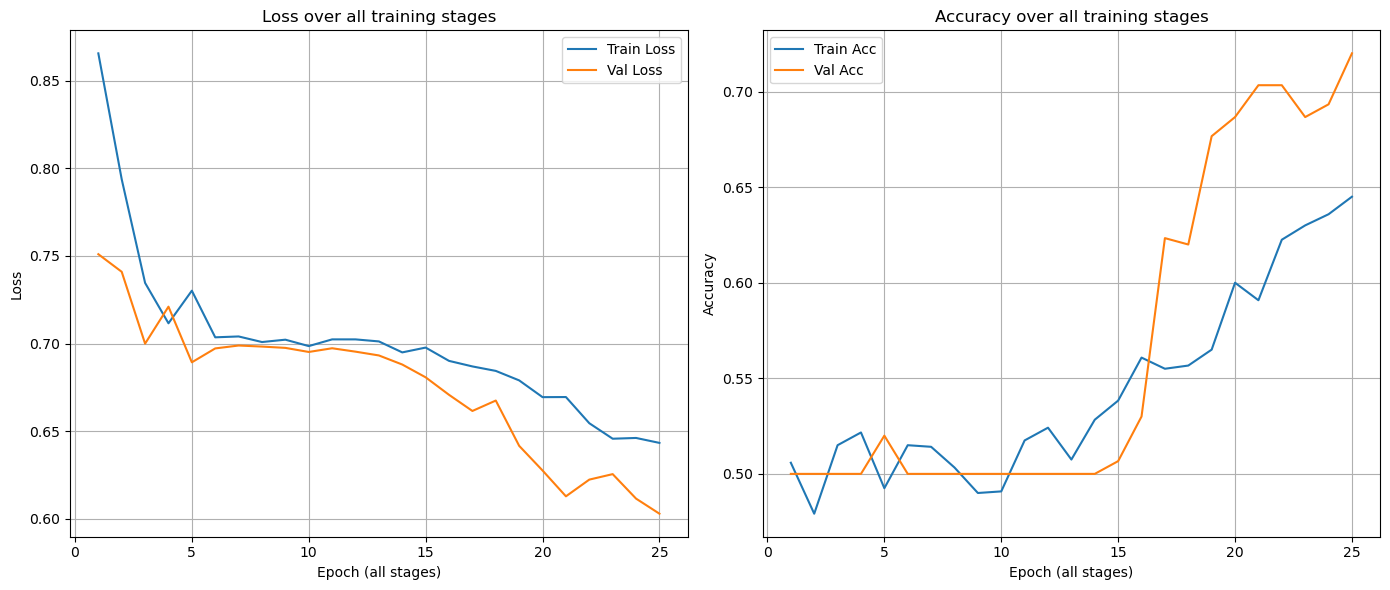

In [26]:
plt.figure(figsize=(14,6))

# ---- LOSS ----
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.xlabel("Epoch (all stages)")
plt.ylabel("Loss")
plt.title("Loss over all training stages")
plt.legend()
plt.grid(True)

# ---- ACCURACY ----
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, label="Train Acc")
plt.plot(epochs, val_acc, label="Val Acc")
plt.xlabel("Epoch (all stages)")
plt.ylabel("Accuracy")
plt.title("Accuracy over all training stages")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


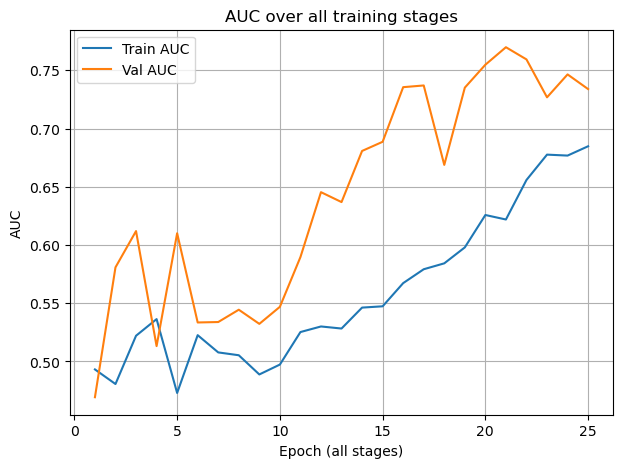

In [27]:
plt.figure(figsize=(7,5))
plt.plot(epochs, train_auc, label="Train AUC")
plt.plot(epochs, val_auc, label="Val AUC")
plt.xlabel("Epoch (all stages)")
plt.ylabel("AUC")
plt.title("AUC over all training stages")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
test_table = pd.read_pickle("test_table.pkl")

In [29]:
import numpy as np
X_test = np.stack(test_table["Frames"].values).astype("float32")
y_test = test_table["Label"].values
meta_test = test_table[["light_conditions", "weather_cloudy", "weather_rain", "scene_highway", "scene_rural"]].values

print("X_test shape:", X_test.shape)
print("meta_test shape:", meta_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (1344, 24, 224, 224, 3)
meta_test shape: (1344, 5)
y_test shape: (1344,)


In [31]:
from tensorflow.keras.models import load_model

best_model = load_model("model_stage2_best.keras",
    custom_objects={"preprocess_input": preprocess_input}, safe_mode=False)

In [32]:
results = best_model.evaluate([X_test, meta_test], y_test, batch_size=4)
print(f"Test Accuracy: {results[1]*100:.2f}%")

336/336 ━━━━━━━━━━━━━━━━━━━━ 645s 2s/step - accuracy: 0.6503 - auc: 0.7223 - loss: 0.6332
Test Accuracy: 65.03%
